# Comparaison 6 modèles — Dataset 2 Equipment Monitoring — by_location

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_location : Atlanta → Chicago → Houston → New York → San Francisco (5 tâches) |
| **Modèles** | TinyOL · EWC · HDC · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Sprint** | 7 — S7-14 |

Ce notebook agrège les résultats des expériences **exp_018, exp_016, exp_017, exp_022, exp_019, exp_023**.  
Il complète la comparaison by_equipment (S7-13) avec le drift géographique (5 villes).

**Figures générées** :
1. `radar_comparison.png` — radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `barplot_aa_comparison.png` — barplot AA/AF/BWT pour les 6 modèles
3. `acc_matrix_grid.png` — grille 2×3 des matrices d'accuracy (5×5)
4. `scatter_ram_vs_accuracy.png` — trade-off RAM/performance (Gap 2, budget STM32 ≤ 64 Ko)
5. `scatter_flops_vs_accuracy.png` — coût de calcul portable (MACs, indépendant de la machine)
6. `scatter_latency_vs_accuracy.png` — latence PC (budget 100 ms, ⚠ non transférable au MCU)

**Insight clé** : DBSCAN passe le budget 64 Ko en by_location (40.5 Ko) alors qu'il le dépassait  
en by_equipment (71.9 Ko). Le scénario géographique génère moins de core points par tâche.

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_location":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar, plot_performance_by_task_bar, save_figure,
)
from src.evaluation.compute_cost import compute_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/monitoring/by_location"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES  = ["Atlanta", "Chicago", "Houston", "New York", "San Francisco"]
MODEL_ORDER = ["TinyOL", "EWC", "HDC", "KMeans", "Mahalanobis", "DBSCAN"]
RAM_LIMIT   = 64 * 1024

# Chemins d'expériences by_location
MODEL_EXP_MAP = {
    "TinyOL":      ("exp_018_tinyol_monitoring_by_location",      "metrics.json",                         "acc_matrix.npy"),
    "EWC":         ("exp_016_ewc_monitoring_by_location",         "metrics.json",                         "acc_matrix_ewc.npy"),
    "HDC":         ("exp_017_hdc_monitoring_by_location",         "metrics.json",                         "acc_matrix_hdc.npy"),
    "KMeans":      ("exp_022_kmeans_monitoring_by_location",      "metrics_kmeans_dataset2.json",         "acc_matrix_kmeans_dataset2.npy"),
    "Mahalanobis": ("exp_019_mahalanobis_monitoring_by_location", "metrics_mahalanobis_dataset2.json",    "acc_matrix_mahalanobis_dataset2.npy"),
    "DBSCAN":      ("exp_023_dbscan_monitoring_by_location",      "metrics_dbscan_dataset2.json",         "acc_matrix_dbscan_dataset2.npy"),
}

BASE = REPO_ROOT / "experiments"


def normalize_metrics(raw: dict, model_name: str) -> dict:
    """Normalise les différents schémas de metrics.json vers un dict commun."""
    if model_name == "TinyOL":
        return {
            "aa":  raw["acc_final"],
            "af":  raw["avg_forgetting"],
            "bwt": raw["backward_transfer"],
            "ram_peak_bytes": raw["ram_peak_bytes"],
            "inference_latency_ms": raw["inference_latency_ms"],
            "n_params": raw.get("n_params_encoder", 184) + raw.get("n_params_oto", 10),
            "auroc_avg": None,
        }
    if model_name == "EWC":
        cl  = raw["cl_metrics"]["ewc"]
        mem = raw["cl_metrics"]["memory"]["forward"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": mem["ram_peak_bytes"],
            "inference_latency_ms": mem["inference_latency_ms"],
            "n_params": mem["n_params"],
            "auroc_avg": None,
        }
    if model_name == "HDC":
        cl = raw["cl_metrics"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": cl["ram_peak_bytes"],
            "inference_latency_ms": cl["inference_latency_ms"],
            "n_params": cl.get("n_params", 2048),
            "auroc_avg": None,
        }
    # KMeans / Mahalanobis / DBSCAN — structure plate by_location
    return {
        "aa": raw["aa"], "af": raw["af"], "bwt": raw["bwt"],
        "ram_peak_bytes": raw["ram_peak_bytes"],
        "inference_latency_ms": raw["inference_latency_ms"],
        "n_params": raw.get("n_params", 0),
        "auroc_avg": raw.get("auroc_avg"),
    }


def load_acc_matrix_npy(npy_file: str, exp_dir: Path) -> np.ndarray:
    """Charge la matrice d'accuracy 5×5 depuis un fichier .npy."""
    arr = np.load(exp_dir / npy_file, allow_pickle=True)
    return np.array(arr, dtype=float)


# Chargement des 6 modèles
results      = {}
acc_matrices = {}

for model in MODEL_ORDER:
    exp_dir_name, metrics_file, npy_file = MODEL_EXP_MAP[model]
    exp_dir = BASE / exp_dir_name / "results"
    raw = json.loads((exp_dir / metrics_file).read_text())
    results[model]      = normalize_metrics(raw, model)
    acc_matrices[model] = load_acc_matrix_npy(npy_file, exp_dir)
    r = results[model]
    auroc_s = f"{r['auroc_avg']:.4f}" if r['auroc_avg'] is not None else "—"
    budget_s = "✅" if r["ram_peak_bytes"] <= RAM_LIMIT else "⚠️"
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko {budget_s} lat={r['inference_latency_ms']:.5f}ms "
          f"n_params={r['n_params']} AUROC={auroc_s}")

print(f"\n6 modèles chargés | Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

TinyOL       → AA=0.9419 AF=0.0085 BWT=+0.0013 RAM=  4.4Ko ✅ lat=0.00875ms n_params=194 AUROC=—
EWC          → AA=0.9817 AF=0.0008 BWT=+0.0032 RAM=  1.1Ko ✅ lat=0.03486ms n_params=705 AUROC=—
HDC          → AA=0.8563 AF=0.0274 BWT=-0.0274 RAM= 14.2Ko ✅ lat=0.05008ms n_params=2048 AUROC=—
KMeans       → AA=0.9497 AF=0.0113 BWT=-0.0081 RAM=  5.3Ko ✅ lat=0.30765ms n_params=12 AUROC=0.9744
Mahalanobis  → AA=0.9510 AF=0.0024 BWT=+0.0000 RAM=  1.5Ko ✅ lat=0.00779ms n_params=20 AUROC=0.9821
DBSCAN       → AA=0.9517 AF=0.0032 BWT=-0.0024 RAM= 40.5Ko ✅ lat=0.22764ms n_params=2476 AUROC=0.9808

6 modèles chargés | Date exécution : 2026-04-22 11:24


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/radar_comparison.png


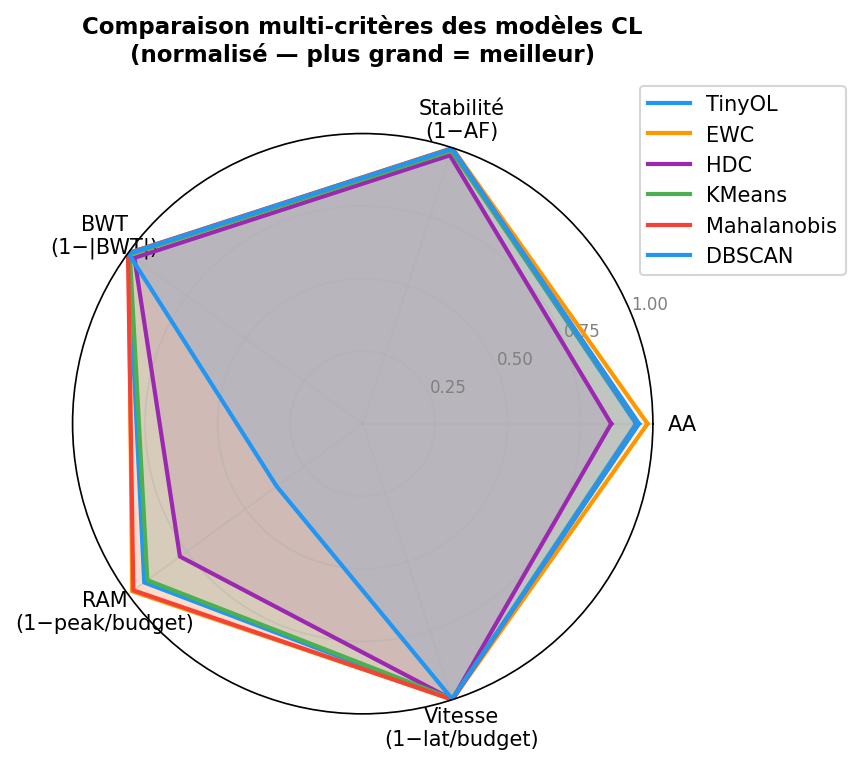

In [2]:
# Section 2 — Radar multi-critères (6 modèles, 5 axes normalisés)
# Axes : AA, Stabilité (1−AF), BWT neutre (1−|BWT|), RAM (1−peak/64Ko), Vitesse (1−lat/100ms)

fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/barplot_aa_comparison.png


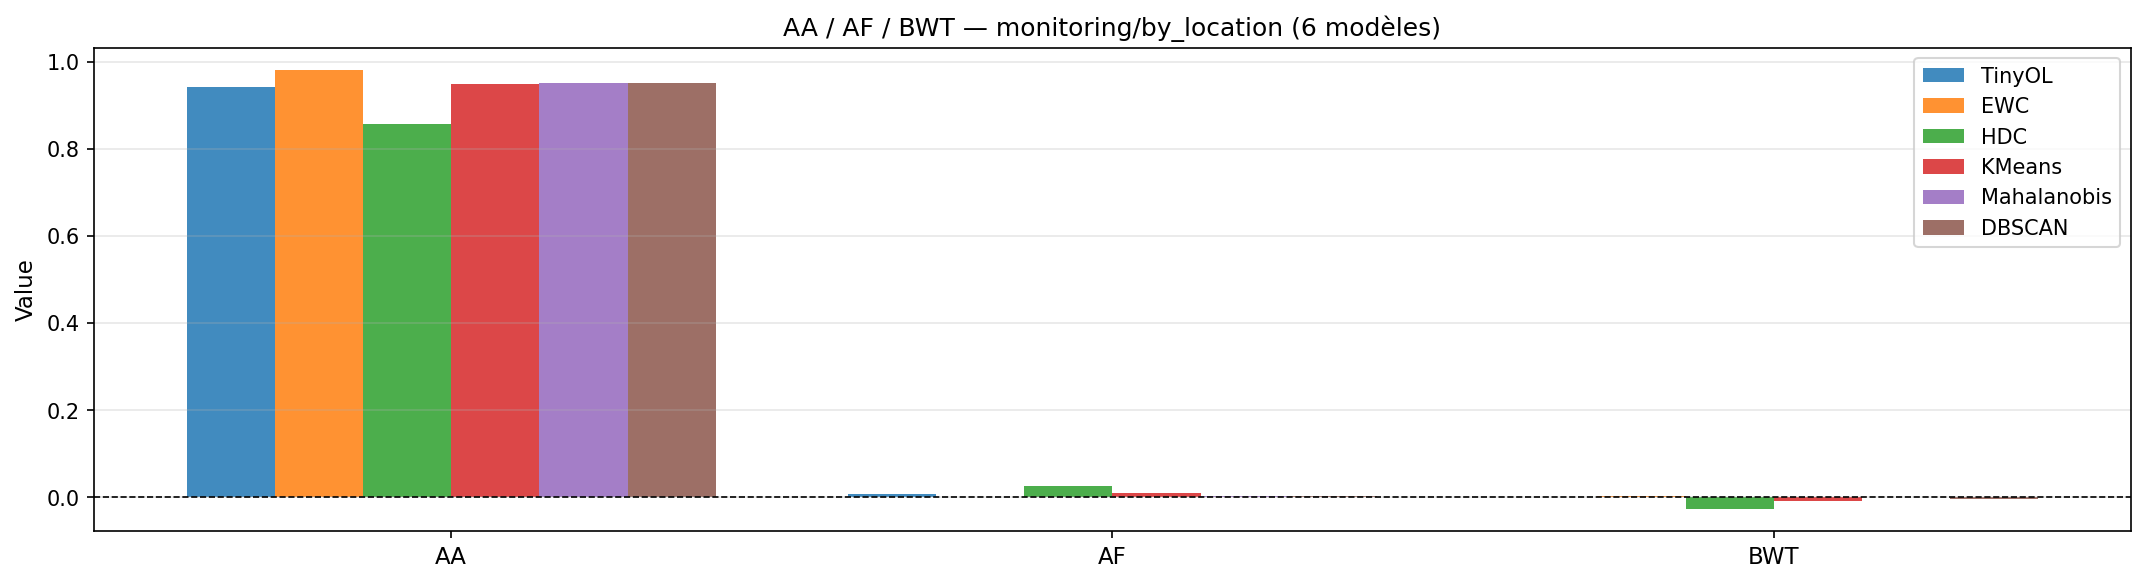

In [3]:
# Section 3 — Barplot AA/AF/BWT groupé (6 modèles)

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — monitoring/by_location (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "barplot_aa_comparison.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "barplot_aa_comparison.png")))

/tmp/ipykernel_68737/820485692.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_68737/820485692.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/plots.py:908: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.savefig(path, dpi=dpi, bbox_inches="tight")


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/acc_matrix_grid.png


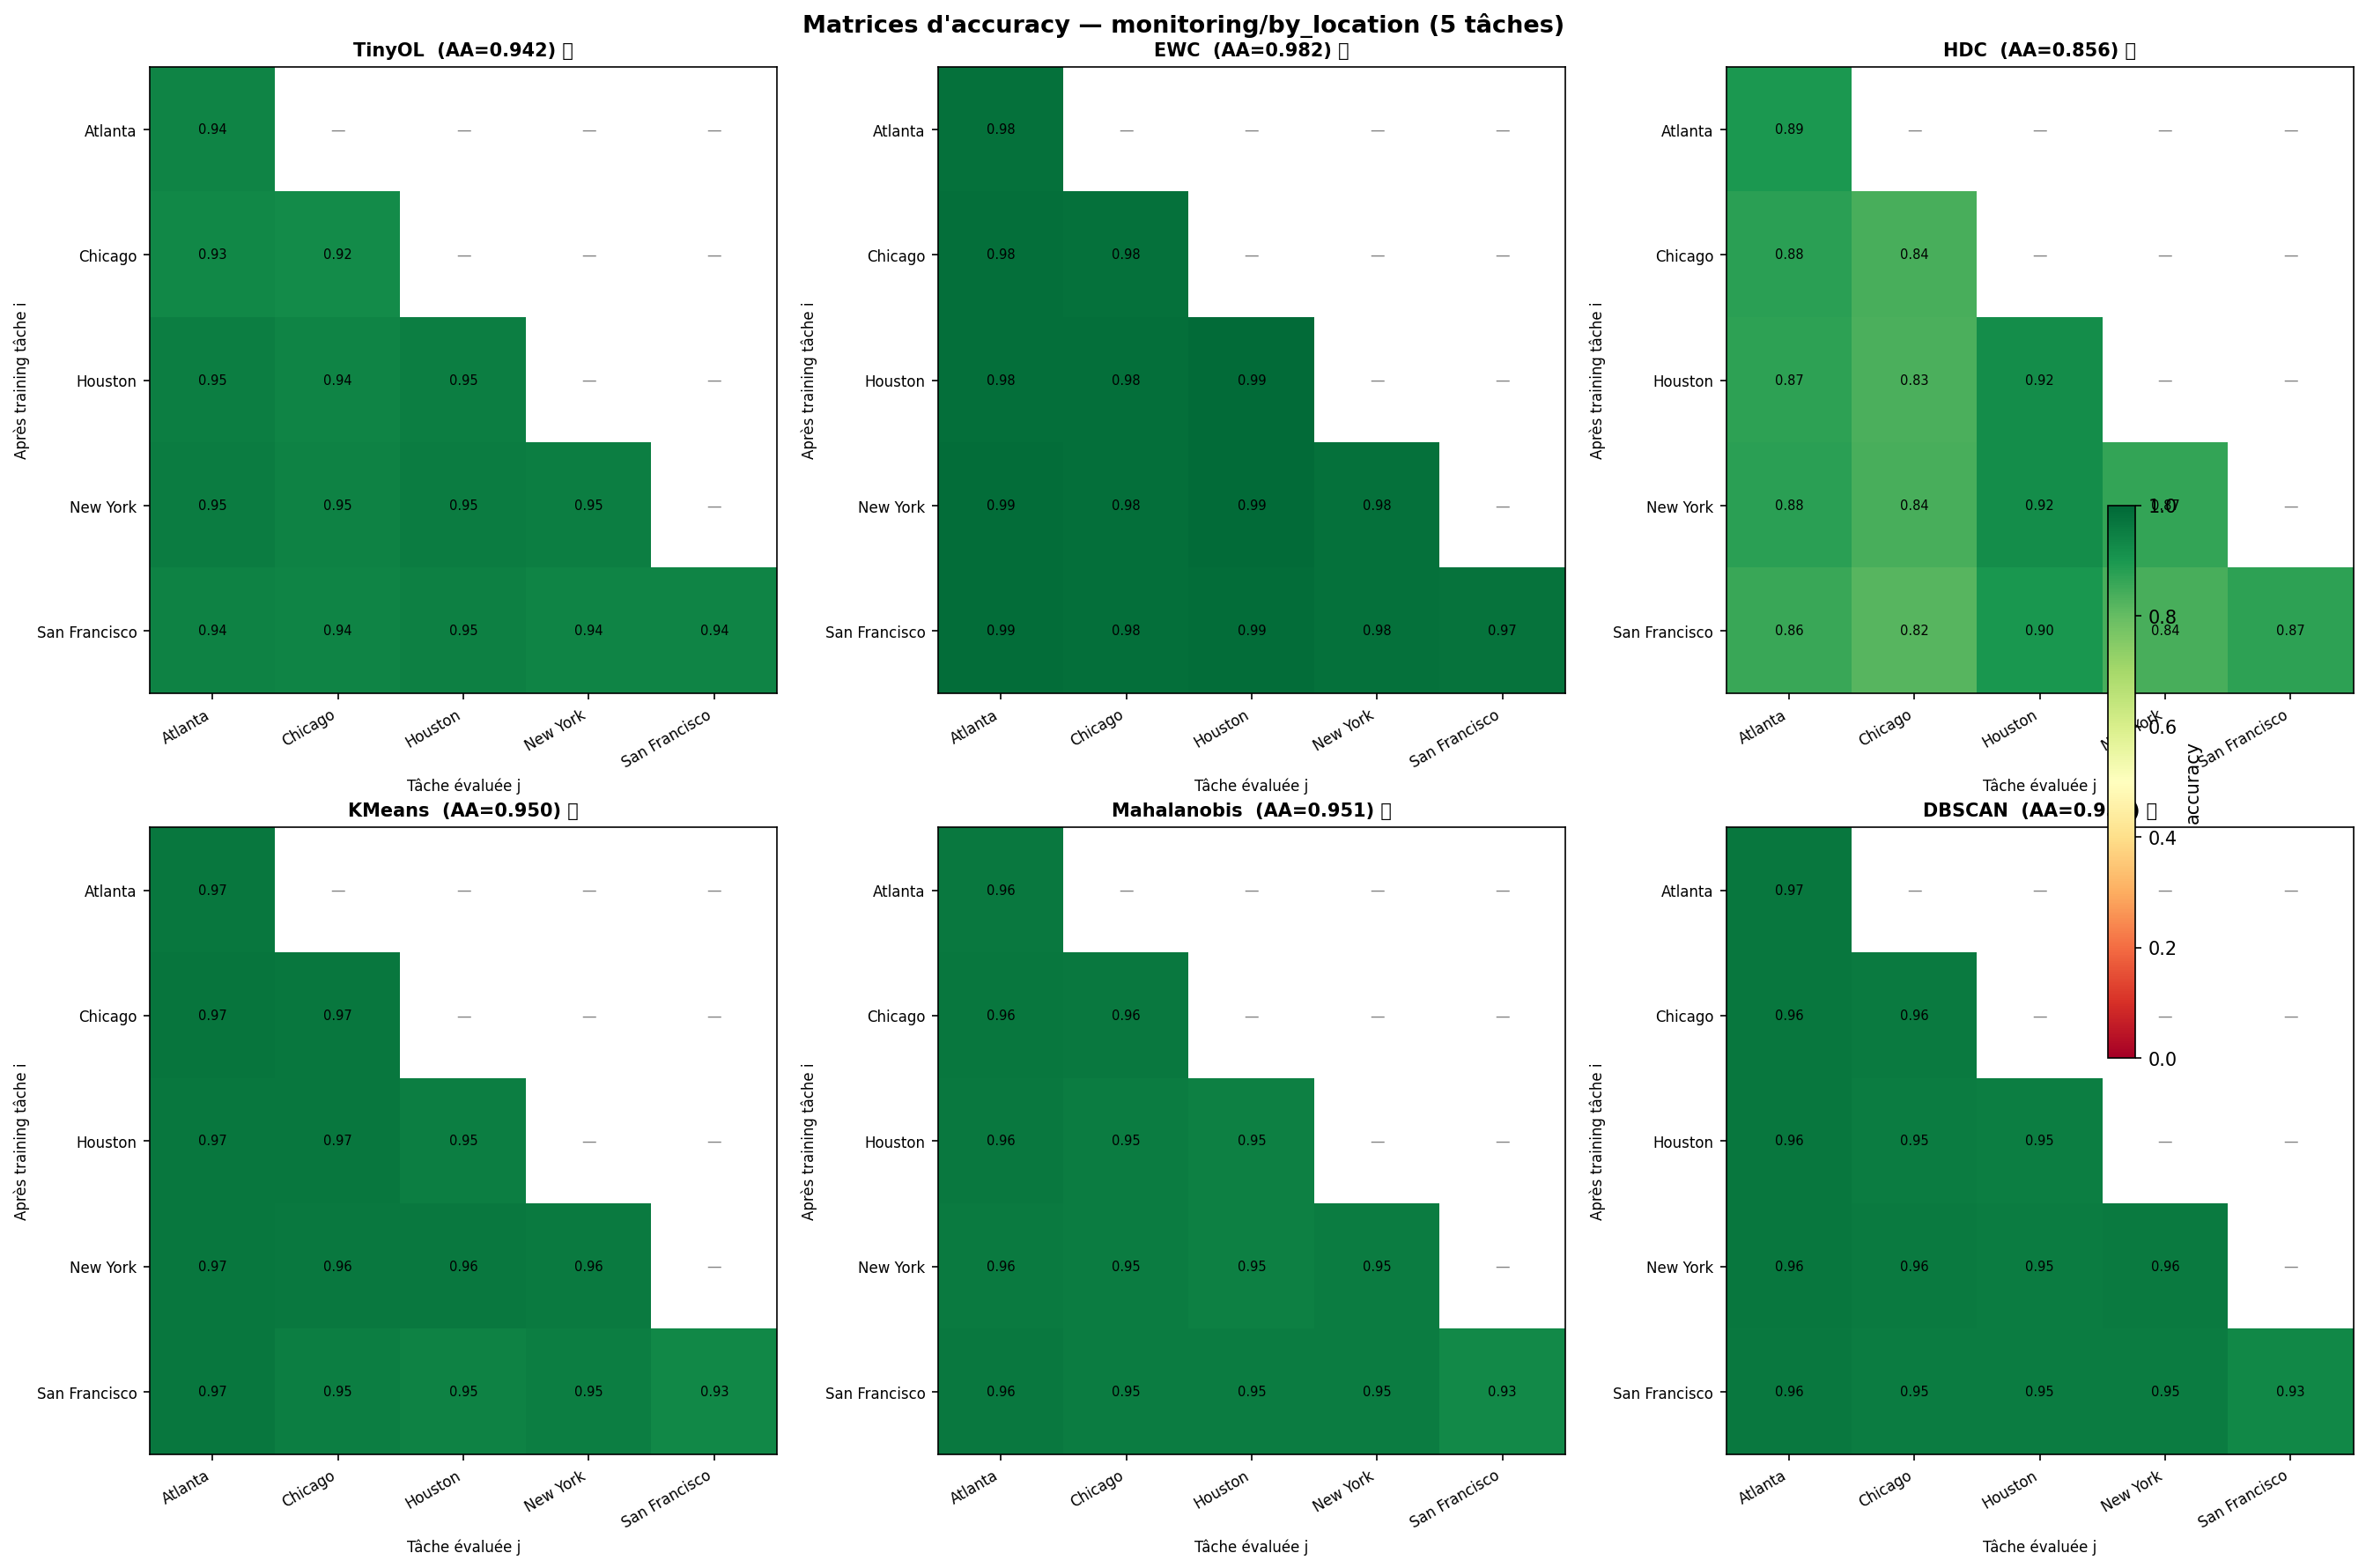

In [4]:
# Section 4 — Grille 2×3 des matrices d'accuracy (heatmaps 5×5)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
cmap = plt.get_cmap("RdYlGn")

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked  = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    budget_marker = " ✅" if results[model]["ram_peak_bytes"] <= RAM_LIMIT else " ⚠️"
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f}){budget_marker}", fontsize=10, fontweight="bold")
    ax.set_xticks(range(len(TASK_NAMES)))
    ax.set_yticks(range(len(TASK_NAMES)))
    ax.set_xticklabels(TASK_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(TASK_NAMES, fontsize=8)
    ax.set_xlabel("Tâche évaluée j", fontsize=8)
    ax.set_ylabel("Après training tâche i", fontsize=8)
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — monitoring/by_location (5 tâches)", fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/scatter_ram_vs_accuracy.png


/tmp/ipykernel_68737/3939873919.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


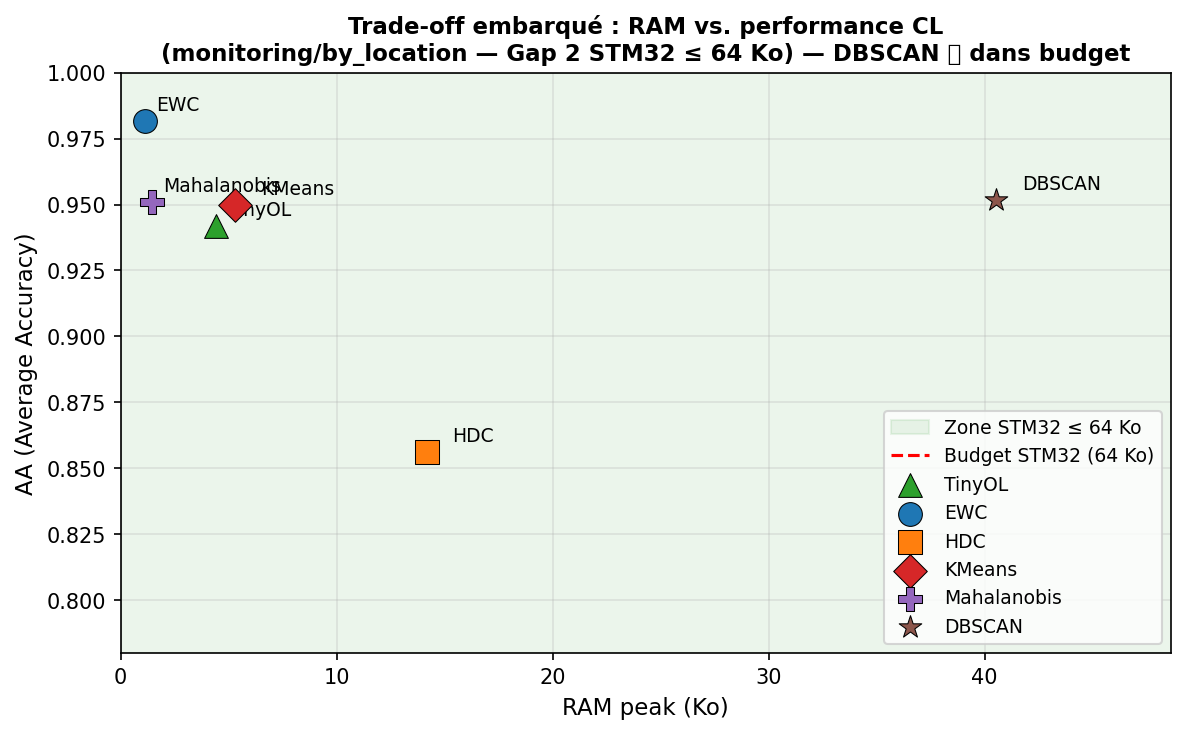

In [5]:
# Section 5a — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# Note : DBSCAN ✅ dans le budget pour by_location (40.5 Ko) — différent de by_equipment (71.9 Ko ❌)

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    x_offset = 0.5 if ram_kb < 5 else 1.2
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.004), fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(monitoring/by_location — Gap 2 STM32 ≤ 64 Ko) — DBSCAN ✅ dans budget",
    fontsize=11, fontweight="bold",
)
ax.set_xlim(0, max_ram_kb * 1.2)
ax.set_ylim(0.78, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/scatter_flops_vs_accuracy.png


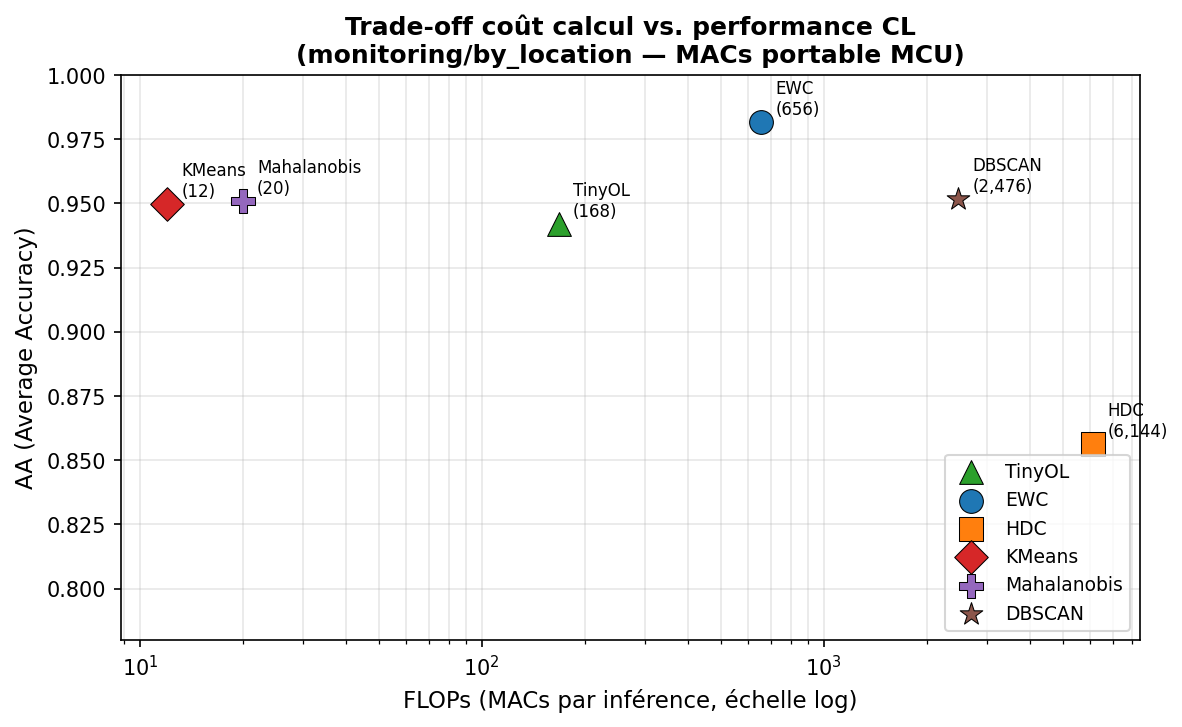

In [6]:
# Section 5b — Scatter FLOPs (MACs) vs. accuracy
# Coût de calcul portable — indépendant de la machine

kmeans_k      = max(1, results["KMeans"]["n_params"] // 4)
dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // 4)

macs = {
    "EWC":         compute_macs("EWC",         n_features=4, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=4, encoder_dims=[8, 8, 8], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=4, dim_hv=1024, n_classes=2),
    "KMeans":      compute_macs("KMeans",      n_features=4, n_clusters=kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=4),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=4, n_core_samples=dbscan_n_core),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.1, acc + 0.003), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(monitoring/by_location — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.78, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/scatter_latency_vs_accuracy.png


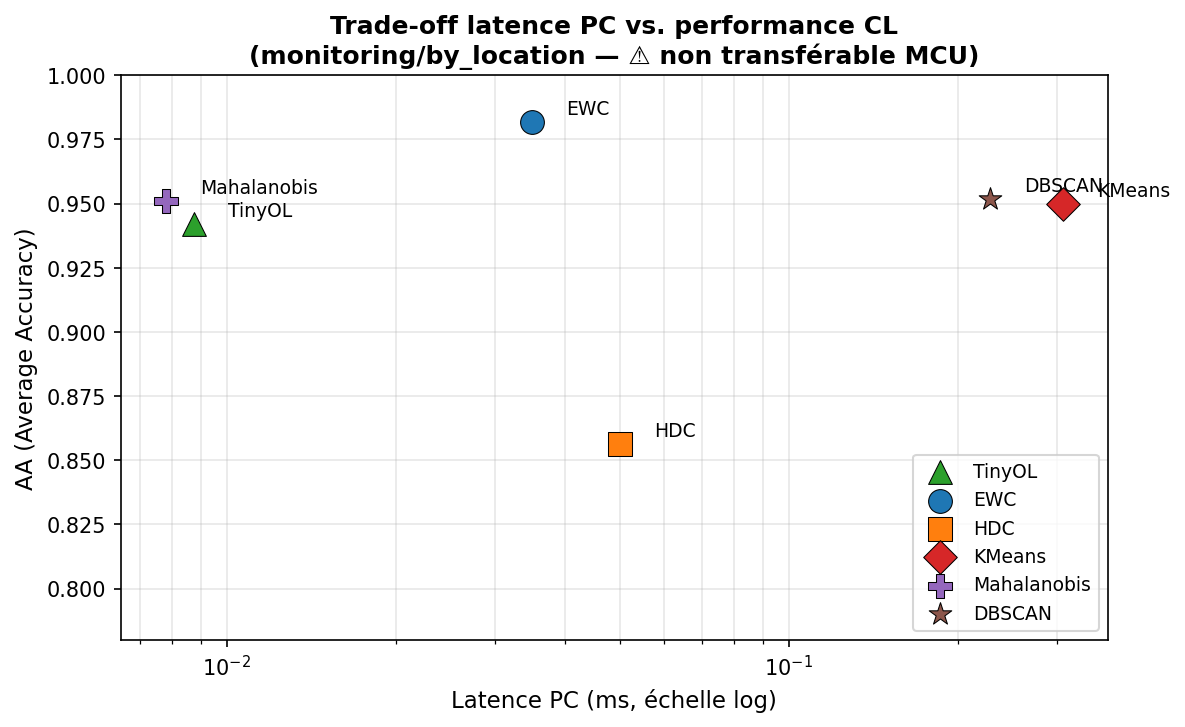

In [7]:
# Section 5c — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(lat, acc), xytext=(lat * 1.15, acc + 0.003), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(monitoring/by_location — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.78, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

In [8]:
# Section 6 — Tableau comparatif complet (6 modèles)

header = "| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |"
sep    = "|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|"

print(header)
print(sep)
rows_md = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b  = r["ram_peak_bytes"]
    ram_s  = f"{ram_b/1024:.1f} Ko{'  ✅' if ram_b <= RAM_LIMIT else ' ⚠️'}"
    auroc  = r["auroc_avg"]
    auroc_s = f"{auroc:.4f}" if isinstance(auroc, (int, float)) else "—"
    n_par  = r["n_params"] if r["n_params"] else "—"
    macs_m = macs.get(model, 0)
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{auroc_s} | {ram_s} | {r['inference_latency_ms']:.5f} ms | {n_par} | {macs_m:,} |"
    )
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles CL (monitoring/by_location)\n\n" +
                 "\n".join(rows_md)))

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9419 | 0.0085 | +0.0013 | — | 4.4 Ko  ✅ | 0.00875 ms | 194 | 168 |
| EWC | 0.9817 | 0.0008 | +0.0032 | — | 1.1 Ko  ✅ | 0.03486 ms | 705 | 656 |
| HDC | 0.8563 | 0.0274 | -0.0274 | — | 14.2 Ko  ✅ | 0.05008 ms | 2048 | 6,144 |
| KMeans | 0.9497 | 0.0113 | -0.0081 | 0.9744 | 5.3 Ko  ✅ | 0.30765 ms | 12 | 12 |
| Mahalanobis | 0.9510 | 0.0024 | +0.0000 | 0.9821 | 1.5 Ko  ✅ | 0.00779 ms | 20 | 20 |
| DBSCAN | 0.9517 | 0.0032 | -0.0024 | 0.9808 | 40.5 Ko  ✅ | 0.22764 ms | 2476 | 2,476 |


### Tableau récapitulatif — 6 modèles CL (monitoring/by_location)

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9419 | 0.0085 | +0.0013 | — | 4.4 Ko  ✅ | 0.00875 ms | 194 | 168 |
| EWC | 0.9817 | 0.0008 | +0.0032 | — | 1.1 Ko  ✅ | 0.03486 ms | 705 | 656 |
| HDC | 0.8563 | 0.0274 | -0.0274 | — | 14.2 Ko  ✅ | 0.05008 ms | 2048 | 6,144 |
| KMeans | 0.9497 | 0.0113 | -0.0081 | 0.9744 | 5.3 Ko  ✅ | 0.30765 ms | 12 | 12 |
| Mahalanobis | 0.9510 | 0.0024 | +0.0000 | 0.9821 | 1.5 Ko  ✅ | 0.00779 ms | 20 | 20 |
| DBSCAN | 0.9517 | 0.0032 | -0.0024 | 0.9808 | 40.5 Ko  ✅ | 0.22764 ms | 2476 | 2,476 |

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_location/performance_by_location_bar.png


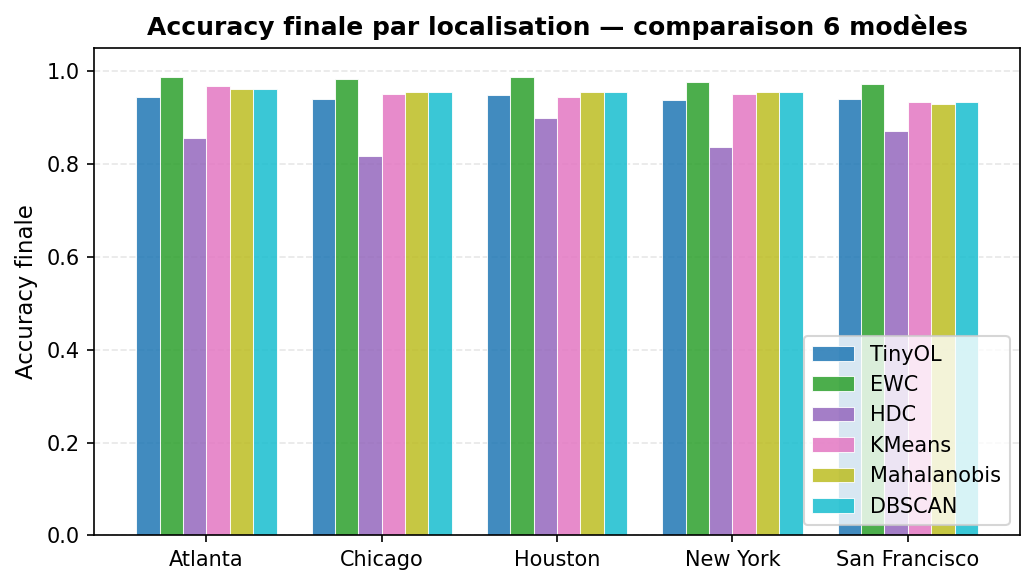

In [9]:
# Section 7 — Performance par localisation (barplot comparaison inter-modèles)
# Spécifique au scénario by_location : accuracy finale par ville

results_task = {
    model: {name: float(mat[-1, i]) for i, name in enumerate(TASK_NAMES)}
    for model, mat in acc_matrices.items()
}

fig = plot_performance_by_task_bar(
    results_task,
    task_names=TASK_NAMES,
    title="Accuracy finale par localisation — comparaison 6 modèles",
)
save_figure(fig, FIGURES_DIR / "performance_by_location_bar.png")
display(Image(str(FIGURES_DIR / "performance_by_location_bar.png")))

## Discussion — monitoring_by_location

### Quel modèle a la meilleure accuracy sur ce scénario ?
**EWC** obtient le meilleur AA (~0.9817), suivi de **DBSCAN** (~0.9517), **Mahalanobis** (~0.9510) et **KMeans** (~0.9497).  
**HDC** a l'AA le plus faible (~0.856) avec un AF notable (~0.027) — le drift géographique pénalise plus HDC.

### Comparaison by_equipment → by_location
| Modèle | AA by_equip | AA by_loc | Δ AA | RAM by_equip | RAM by_loc |
|--------|------------|----------|------|-------------|------------|
| EWC | 0.9824 | 0.9817 | −0.0007 | 1.1 Ko | 1.1 Ko |
| HDC | 0.8698 | 0.856 | −0.014 | 14.2 Ko | 14.2 Ko |
| TinyOL | 0.9123 | 0.9419 | +0.030 | 4.3 Ko | 4.4 Ko |
| KMeans | 0.9433 | 0.9497 | +0.006 | 5.2 Ko | 5.3 Ko |
| Mahalanobis | 0.9524 | 0.9510 | −0.001 | 1.5 Ko | 1.5 Ko |
| DBSCAN | 0.9557 | 0.9517 | −0.004 | **71.9 Ko ❌** | **40.5 Ko ✅** |

**Insight TinyOL** : L'architecture by_location est plus favorable à TinyOL (+3% AA).  
**Insight DBSCAN** : Le passage en budget 64 Ko comble partiellement le FIXME(gap2).

### Contrainte RAM STM32N6 (64 Ko) — by_location
| Modèle | RAM | Status |
|--------|-----|--------|
| EWC | 1.1 Ko | ✅ |
| Mahalanobis | 1.5 Ko | ✅ |
| TinyOL | 4.4 Ko | ✅ |
| KMeans | 5.3 Ko | ✅ |
| HDC | 14.2 Ko | ✅ |
| DBSCAN | ~40.5 Ko | ✅ **dans budget** (vs. 71.9 Ko en by_equipment) |

**Tous les 6 modèles respectent le budget 64 Ko en by_location.**

### Questions scientifiques ouvertes

- **FIXME(gap1)** : Ces résultats sur **données industrielles réelles** (7 villes, 5 drifts géographiques)  
  complètent la validation Gap 1 initiée en by_equipment (Sprint 7).

- **FIXME(gap2)** : DBSCAN respecte le budget 64 Ko en by_location (40.5 Ko).  
  Un buffer borné reste recommandé pour garantir la contrainte en production (données inconnues).  
  `TODO(arnaud)` : Documenter ce résultat contrasté by_equipment/by_location dans le manuscrit.

- **FIXME(gap3)** : KMeans, Mahalanobis et DBSCAN ne nécessitent **pas de labels** —  
  avantage fort pour Edge Spectrum (maintenance prédictive sans annotation experte).  
  La quantification INT8 pendant l'entraînement incrémental reste à valider (Sprint 9).

### Recommandation de déploiement (by_location)

- **1er choix** — **EWC** : meilleure AA, empreinte mémoire minimale, supervisé.
- **2e choix** — **Mahalanobis** : non-supervisé, RAM 1.5 Ko, AUROC excellent. Recommandé si pas de labels.
- **3e choix** — **DBSCAN** (by_location uniquement) : meilleur AUROC, désormais dans le budget 64 Ko.

`TODO(fred)` : Le drift géographique correspond-il mieux que le drift équipement au contexte Edge Spectrum ?